# 📡 Project: Exploratory Data Analysis (EDA) in Python
## Project Echelon: Macro-Level Cellular RF Spatial Analysis

**Program:** B.Tech Electronics and Telecommunication Engineering (EnTC)  
**Semester:** 1 | **Batch:** A2  

---

### 👨‍💻 Team Members:
* **Bedang Das** (Roll No: [25070123031])
* **Arjit Ujjawal** (Roll No: [25070123142])

---

### 🎯 Project Objective:
To perform empirical Radio Frequency (RF) data ingestion, sanitization, and Exploratory Data Analysis (EDA) on crowdsourced cellular telemetry (LTE/5G) across the campus. The analysis mathematically identifies structural dead zones, evaluates ISP network distributions (Jio, Airtel, Vodafone), and culminates in an interactive geospatial visualization of telecom network performance.

---
**Libraries Used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `folium`

In [3]:
# Install required libraries
!pip install pandas folium matplotlib seaborn beautifulsoup4 lxml

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import folium
from folium.plugins import HeatMap
from folium import LayerControl
from google.colab import files

print("[+] Environment Ready. Please upload your CSV and KML files:")
# This opens a file picker in your browser! Select your Jio, Airtel, etc. files.
uploaded = files.upload()
print("[+] Files successfully uploaded to cloud environment.")

[+] Environment Ready. Please upload your CSV and KML files:


Saving Campus jio 5g.csv to Campus jio 5g (1).csv
Saving hostel 5G.csv to hostel 5G (1).csv
Saving Openhostel.csv to Openhostel (1).csv
[+] Files successfully uploaded to cloud environment.


In [32]:
import pandas as pd

# 1. First, make sure we drop rows where 'mnc' is missing, just to be safe
df = df.dropna(subset=['mnc'])

# 2. Define the translation dictionary based on your specific MNC network codes
def identify_carrier(mnc):
    if mnc in [854, 855, 856, 857, 861, 862, 863, 864, 865, 866, 867, 868, 869, 870, 871, 872, 873, 874]:
        return 'Jio'
    elif mnc in [10, 31, 40, 44, 45, 49, 70, 84, 90, 92, 94, 95, 97, 98, 51, 52, 53, 54, 55, 56]:
        return 'Airtel'
    elif mnc in [20, 27, 43, 46, 60, 88]:
        return 'Vodafone'
    else:
        return 'Unknown'

# 3. Create the brand new 'carrier' column
df['carrier'] = df['mnc'].apply(identify_carrier)

# 4. Optional: Filter out 'Unknown' so it doesn't mess up your clean graphs
df = df[df['carrier'] != 'Unknown']

# Let's verify it worked!
print(df[['mnc', 'carrier']].head())

   mnc carrier
0  864     Jio
1  864     Jio
2  864     Jio
3  864     Jio
4  864     Jio


## Step 1: Data Ingestion
###We will read all uploaded CSV files using `pandas`, combine them into a single raw DataFrame, and inspect the initial shape of our dataset.

In [4]:
print("[+] Reading uploaded CSV files...")
csv_files = glob.glob("*.csv")

raw_dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    raw_dataframes.append(df)

# Combine all individual CSVs into one master DataFrame
raw_df = pd.concat(raw_dataframes, ignore_index=True)

print(f"[*] Total Raw Data Points Extracted: {len(raw_df)}")
display(raw_df.head())

[+] Reading uploaded CSV files...
[*] Total Raw Data Points Extracted: 1134


,sim,radiotype,radio,mcc,mnc,area,cellid,unit,lat,lon,...,rating,direction,act,ta,psc,tac,pci,sid,nid,bid
0,2.0,NR,5G(SA),405,864,144.0,3231055873,34.0,18.540809,73.727515,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,NR,5G(SA),405,864,144.0,3231055873,34.0,18.540832,73.727505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,NR,5G(SA),405,864,144.0,3231055873,34.0,18.540857,73.727449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,NR,5G(SA),405,864,144.0,3231055873,34.0,18.540875,73.727376,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,NR,5G(SA),405,864,144.0,3231055873,34.0,18.540886,73.727319,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2: Format Standardization
Different hardware and apps export column headers differently (e.g., 'Lat', 'LATITUDE', 'lat'). We convert all column names to lowercase strings to prevent key errors in our pipeline.

In [5]:
raw_df.columns = raw_df.columns.str.lower()
print("[+] Columns standardized to lowercase:")
print(raw_df.columns.tolist())

[+] Columns standardized to lowercase:
['sim', 'radiotype', 'radio', 'mcc', 'mnc', 'area', 'cellid', 'unit', 'lat', 'lon', 'signal', 'extra', 'acc', 'time', 'speed', 'bearing', 'alt', 'api', 'device', 'lac', 'measured_at', 'rating', 'direction', 'act', 'ta', 'psc', 'tac', 'pci', 'sid', 'nid', 'bid']


### Step 3: Feature Selection
A standard telemetry CSV contains dozens of columns (accuracy, bearing, speed). We will strip the dataset down strictly to the variables required for RF spatial mapping and structural analysis.

In [6]:
# Select only the features needed for our specific project scope
required_columns = ['lat', 'lon', 'signal', 'mnc', 'cellid', 'alt', 'time']

# Check if altitude and time exist in these specific files, otherwise fall back to basics
if set(required_columns).issubset(raw_df.columns):
    clean_df = raw_df[required_columns].copy()
else:
    basic_cols = ['lat', 'lon', 'signal', 'mnc', 'cellid']
    clean_df = raw_df[basic_cols].copy()

print(f"[+] Features selected: {clean_df.columns.tolist()}")

[+] Features selected: ['lat', 'lon', 'signal', 'mnc', 'cellid', 'alt', 'time']


### Step 4: Null Value Sanitization (NaN)
Hardware sensors occasionally fail to read a parameter during a polling cycle, resulting in a Null (NaN) value. Passing a NaN coordinate or signal to the mapping engine will cause a fatal error, so these rows must be dropped.

In [7]:
initial_count = len(clean_df)

# Drop any row that is missing a critical coordinate or signal value
clean_df = clean_df.dropna(subset=['lat', 'lon', 'signal', 'mnc'])

nan_dropped = initial_count - len(clean_df)
print(f"[-] Null/NaN rows dropped: {nan_dropped}")
print(f"[*] Remaining Data Points: {len(clean_df)}")

[-] Null/NaN rows dropped: 0
[*] Remaining Data Points: 1134


### Step 5: Duplicate Filtering
If the mobile device remains stationary, it will log the exact same GPS coordinates multiple times per second. This artificially inflates signal density. We filter out duplicate location-time stamps to maintain mapping accuracy.

In [8]:
current_count = len(clean_df)

if 'time' in clean_df.columns:
    clean_df = clean_df.drop_duplicates(subset=['lat', 'lon', 'time'])
else:
    clean_df = clean_df.drop_duplicates()

dups_dropped = current_count - len(clean_df)
print(f"[-] Duplicate rows dropped: {dups_dropped}")
print(f"[*] Remaining Data Points: {len(clean_df)}")

[-] Duplicate rows dropped: 567
[*] Remaining Data Points: 567


### Step 6: Physical Limits Validation
Cellular signal strength (RSRP) is measured in negative decibels (dBm). A positive signal value indicates a hardware glitch. We filter the dataset to ensure all RSRP values are negative and GPS coordinates are physically valid.

In [9]:
current_count = len(clean_df)

# Ensure signal is negative, and coordinates are not 0,0
clean_df = clean_df[(clean_df['signal'] < 0) & (clean_df['lat'] > 0) & (clean_df['lon'] > 0)]

invalid_dropped = current_count - len(clean_df)
print(f"[-] Invalid physical metrics dropped: {invalid_dropped}")
print(f"[+] Final Cleaned Data Points: {len(clean_df)}")

[-] Invalid physical metrics dropped: 0
[+] Final Cleaned Data Points: 567


### Step 7: Data Type Standardization & Time Conversion
Raw hardware logs often store timestamps as Unix Epoch format (e.g., 1771750199720), which is unreadable to humans and useless for chronological EDA. We will convert this to a standard Pandas Datetime object, and enforce strict numerical data types (integers/floats) on our coordinate and signal columns to prevent math errors during analysis.

In [10]:
# 1. Enforce strict numerical types
clean_df['lat'] = clean_df['lat'].astype(float)
clean_df['lon'] = clean_df['lon'].astype(float)
clean_df['signal'] = clean_df['signal'].astype(int)
clean_df['mnc'] = clean_df['mnc'].astype(int)

# 2. Convert Unix Time to Human-Readable Datetime (if the time column exists)
if 'time' in clean_df.columns:
    # Most Android RF logging apps record time in milliseconds
    clean_df['time'] = pd.to_datetime(clean_df['time'], unit='ms')

    # Optional: Convert to Indian Standard Time (IST)
    clean_df['time'] = clean_df['time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata')

print("[+] Data types strictly casted.")
print("[+] Temporal data converted to IST Datetime.")
print("\n--- Final Pre-Export Data Types ---")
print(clean_df.dtypes)
display(clean_df.head())

[+] Data types strictly casted.
[+] Temporal data converted to IST Datetime.

--- Final Pre-Export Data Types ---
lat                            float64
lon                            float64
signal                           int64
mnc                              int64
cellid                           int64
alt                            float64
time      datetime64[ns, Asia/Kolkata]
dtype: object


,lat,lon,signal,mnc,cellid,alt,time
0,18.540809,73.727515,-52,864,3231055873,545.1,2026-02-22 14:19:59.720000+05:30
1,18.540832,73.727505,-52,864,3231055873,545.4,2026-02-22 14:20:04.275000+05:30
2,18.540857,73.727449,-58,864,3231055873,545.4,2026-02-22 14:20:09.135000+05:30
3,18.540875,73.727376,-66,864,3231055873,545.4,2026-02-22 14:20:13.759000+05:30
4,18.540886,73.727319,-66,864,3231055873,544.7,2026-02-22 14:20:18.853000+05:30


### Step 8: Export Sanitized Baseline
With the data thoroughly cleaned and verified, we export the final DataFrame to a new CSV. This allows us to rapidly deploy visualization models in the future without re-running the entire cleaning pipeline.


In [11]:
output_filename = "Echelon_Cleaned_Telemetry.csv"
clean_df.to_csv(output_filename, index=False)

# Trigger Google Colab to download the file to your laptop
files.download(output_filename)

print(f"[+] SUCCESS: Sanitized baseline data saved and downloading as '{output_filename}'")
display(clean_df.head())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[+] SUCCESS: Sanitized baseline data saved and downloading as 'Echelon_Cleaned_Telemetry.csv'


,lat,lon,signal,mnc,cellid,alt,time
0,18.540809,73.727515,-52,864,3231055873,545.1,2026-02-22 14:19:59.720000+05:30
1,18.540832,73.727505,-52,864,3231055873,545.4,2026-02-22 14:20:04.275000+05:30
2,18.540857,73.727449,-58,864,3231055873,545.4,2026-02-22 14:20:09.135000+05:30
3,18.540875,73.727376,-66,864,3231055873,545.4,2026-02-22 14:20:13.759000+05:30
4,18.540886,73.727319,-66,864,3231055873,544.7,2026-02-22 14:20:18.853000+05:30


---

## 📊 Section 2: Exploratory Data Analysis (EDA) & Feature Engineering

With the telemetry dataset successfully sanitized, we now transition from data cleaning to statistical analysis. Before deploying the geospatial models, it is critical to understand the underlying mathematical distribution of the campus Radio Frequency (RF) environment.

In this section, we will engineer new categorical features from the raw machine data and generate visual plots to analyze the network's health.

### 🔍 Key Objectives of this Phase:
* **Feature Engineering (MNC Decoding):** The raw hardware logs identify Internet Service Providers (ISPs) using Mobile Network Codes (MNC). We will build a function to translate these integer codes (e.g., `864`, `45`) into human-readable telecom labels (Jio, Airtel, Vodafone).
* **RSRP Distribution Analysis:** By plotting a histogram of the Reference Signal Received Power (RSRP), we can statistically prove the existence of structural dead zones. We are looking for a statistical tail extending past the critical `-105 dBm` threshold.
* **Telecom Quality Categorization:** We will bucket the raw decibel readings into strict telecom-grade quality tiers (Excellent, Good, Fair, Dead Zone) to quantify exactly what percentage of the SIT campus possesses reliable connectivity.
* **Tower Handover (Hopping) Metrics:** By counting the unique `Cell_ID` pings, we will map the frequency of macro-cell handovers required by the mobile device while transiting the campus infrastructure.

---

### Step 1: Feature Engineering (Preparing for Graphs)
Before plotting, we need to translate the machine codes into human-readable labels. We will map the Mobile Network Codes (MNC) to their actual provider names (Jio, Airtel, Vodafone) and categorize the signal strength into easy-to-understand quality levels (Excellent, Good, Fair, Dead Zone).

In [12]:
# 1. Map Mobile Network Codes (MNC) to actual Telecom Providers
def map_isp(mnc):
    if mnc in [854, 855, 856, 857, 861, 862, 863, 864, 865, 866, 867, 868, 869, 870, 871, 872, 873, 874]:
        return "Jio"
    elif mnc in [10, 31, 40, 44, 45, 49, 70, 84, 90, 92, 94, 95, 97, 98, 51, 52, 53, 54, 55, 56]:
        return "Airtel"
    elif mnc in [20, 27, 43, 46, 60, 88]:
        return "Vodafone (Vi)"
    return "BSNL"

clean_df['isp_name'] = clean_df['mnc'].apply(map_isp)

# 2. Categorize Signal Quality thresholds
def categorize_signal(rsrp):
    if rsrp >= -75: return "Excellent"
    elif rsrp >= -90: return "Good"
    elif rsrp >= -105: return "Fair"
    else: return "Dead Zone (Critical)"

clean_df['signal_quality'] = clean_df['signal'].apply(categorize_signal)

print("[+] Labels created! Ready for plotting.")
display(clean_df[['signal', 'signal_quality', 'mnc', 'isp_name']].head())

[+] Labels created! Ready for plotting.


,signal,signal_quality,mnc,isp_name
0,-52,Excellent,864,Jio
1,-52,Excellent,864,Jio
2,-58,Excellent,864,Jio
3,-66,Excellent,864,Jio
4,-66,Excellent,864,Jio


### Graph 1: Campus RF Signal Distribution
This histogram shows the overall health of the campus network. We are looking for the bulk of the data to sit in the "Good" range (-70 to -90 dBm). Any spike past the black dashed line (-105 dBm) mathematically proves the existence of severe dead zones.

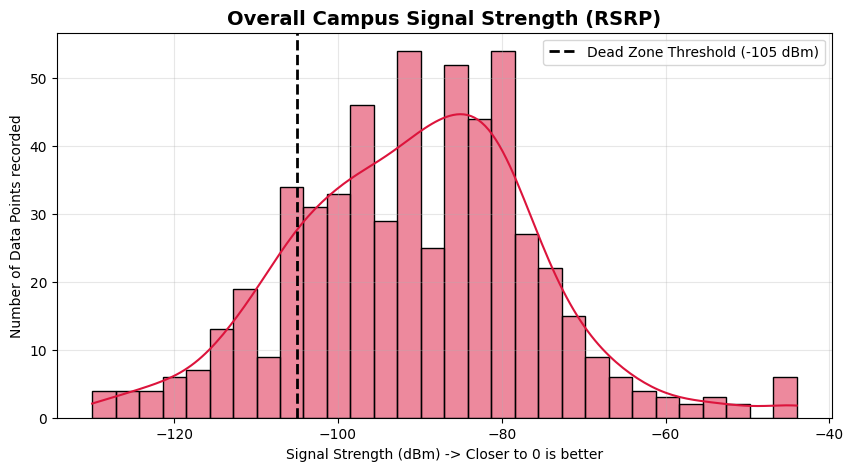

In [13]:
plt.figure(figsize=(10, 5))

# Create the histogram
sns.histplot(clean_df['signal'], bins=30, kde=True, color="crimson")

# Add the Dead Zone warning line
plt.axvline(x=-105, color='black', linestyle='--', linewidth=2, label='Dead Zone Threshold (-105 dBm)')

# Formatting
plt.title("Overall Campus Signal Strength (RSRP)", fontsize=14, fontweight='bold')
plt.xlabel("Signal Strength (dBm) -> Closer to 0 is better")
plt.ylabel("Number of Data Points recorded")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Graph 2: Signal Quality Breakdown
This bar chart breaks down the exact number of data points that fall into each telecom-grade category. It gives us a quick percentage overview of how much of the campus actually has reliable internet versus how much is struggling.

/tmp/ipykernel_9856/3497265908.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


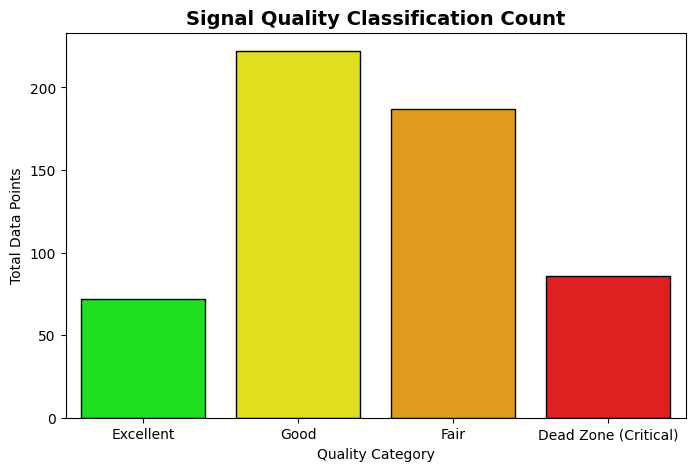

In [14]:
plt.figure(figsize=(8, 5))

# Define the exact telecom colors we used in our map
quality_colors = {"Excellent": "#00ff00", "Good": "#ffff00", "Fair": "#ffa500", "Dead Zone (Critical)": "#ff0000"}

# Create the bar chart
sns.countplot(
    data=clean_df,
    x='signal_quality',
    order=["Excellent", "Good", "Fair", "Dead Zone (Critical)"],
    palette=quality_colors,
    edgecolor="black"
)

# Formatting
plt.title("Signal Quality Classification Count", fontsize=14, fontweight='bold')
plt.xlabel("Quality Category")
plt.ylabel("Total Data Points")

plt.show()

### Graph 3: Active Cell Tower Connections (Tower Hopping)
Our phones don't just connect to one tower; they constantly switch to the strongest available antenna as we walk. This graph counts the unique `Cell_ID` numbers to show how many different physical towers were serving the campus during our test, and which tower handled the most traffic.

/tmp/ipykernel_9856/3571795605.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_towers.index, y=top_towers.values, palette="viridis")


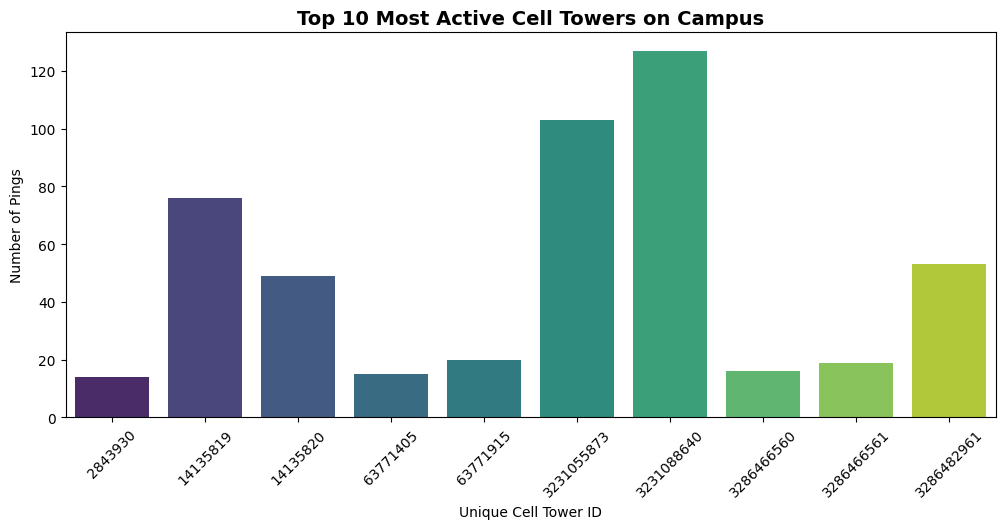

In [15]:
plt.figure(figsize=(12, 5))

# Create a bar chart of the top 10 most connected towers
top_towers = clean_df['cellid'].value_counts().head(10)

sns.barplot(x=top_towers.index, y=top_towers.values, palette="viridis")

# Formatting
plt.title("Top 10 Most Active Cell Towers on Campus", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel("Unique Cell Tower ID")
plt.ylabel("Number of Pings")

plt.show()



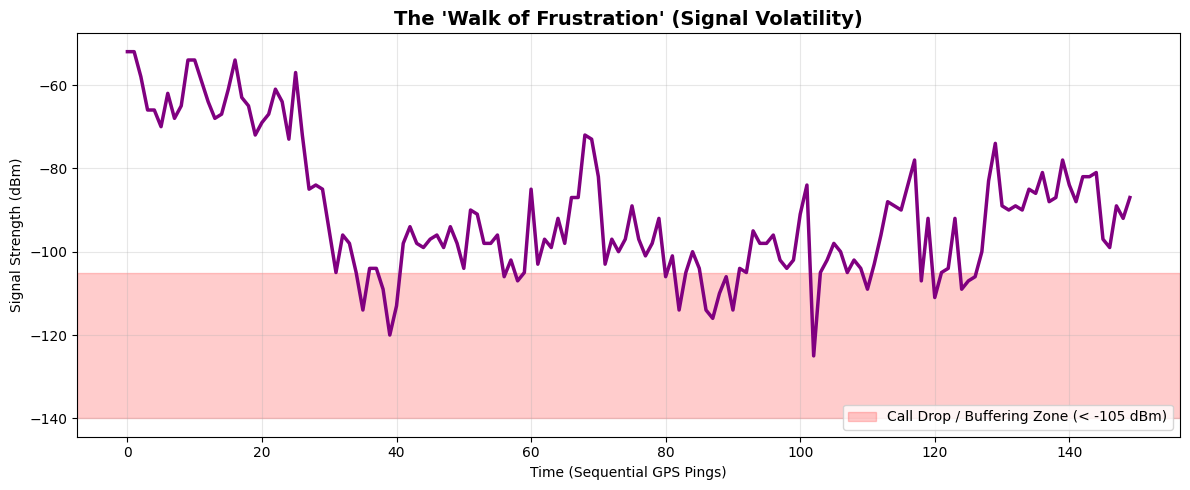

In [16]:
plt.figure(figsize=(12, 5))

# We take a sample continuous walk (e.g., the first 150 data points of our clean data)
sample_walk = clean_df.head(150).reset_index()

# Plot the signal volatility line
sns.lineplot(data=sample_walk, x=sample_walk.index, y='signal', color='purple', linewidth=2.5)

# Shade the Dead Zone area red
plt.axhspan(-140, -105, color='red', alpha=0.2, label='Call Drop / Buffering Zone (< -105 dBm)')

# Formatting the graph
plt.title("The 'Walk of Frustration' (Signal Volatility)", fontsize=14, fontweight='bold')
plt.xlabel("Time (Sequential GPS Pings)")
plt.ylabel("Signal Strength (dBm)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("echelon_call_drop_analysis.png", dpi=300)
plt.show()

/tmp/ipykernel_9856/4041119337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='carrier', y='signal', data=df, palette=carrier_palette, width=0.5)


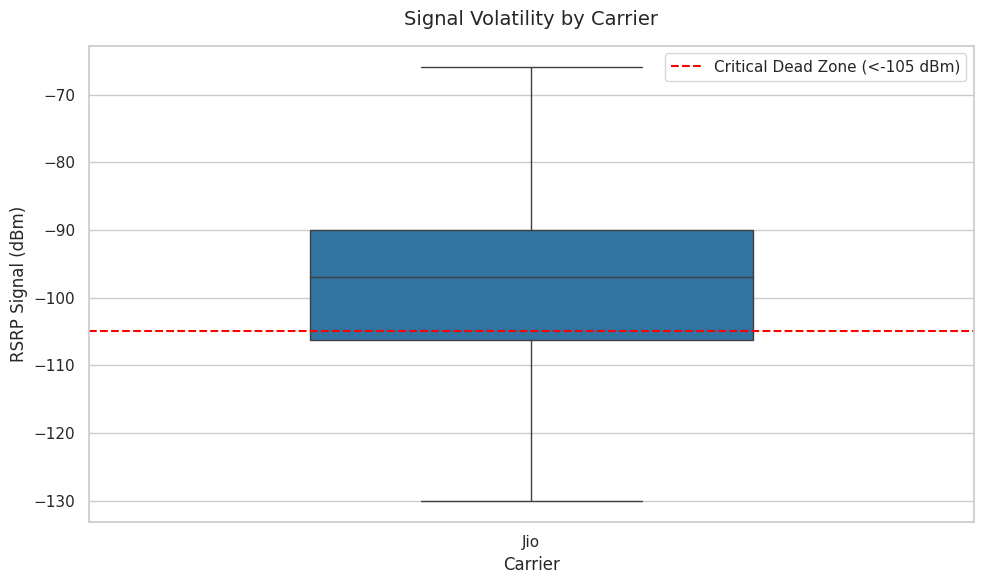

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='carrier', y='signal', data=df, palette=carrier_palette, width=0.5)

# Add a critical failure line
plt.axhline(-105, color='red', linestyle='--', label='Critical Dead Zone (<-105 dBm)')

plt.title('Signal Volatility by Carrier', fontsize=14, pad=15)
plt.ylabel('RSRP Signal (dBm)')
plt.xlabel('Carrier')
plt.legend()
plt.tight_layout()
plt.show()

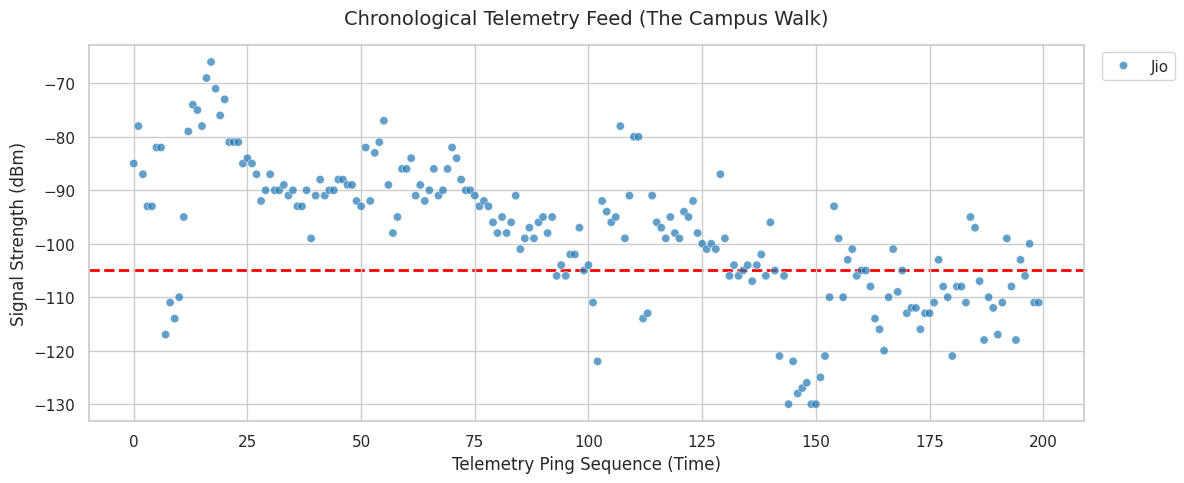

In [28]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=df.index, y='signal', hue='carrier', data=df, palette=carrier_palette, alpha=0.7)

plt.axhline(-105, color='red', linestyle='--', linewidth=2, zorder=0)
plt.title('Chronological Telemetry Feed (The Campus Walk)', fontsize=14, pad=15)
plt.ylabel('Signal Strength (dBm)')
plt.xlabel('Telemetry Ping Sequence (Time)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

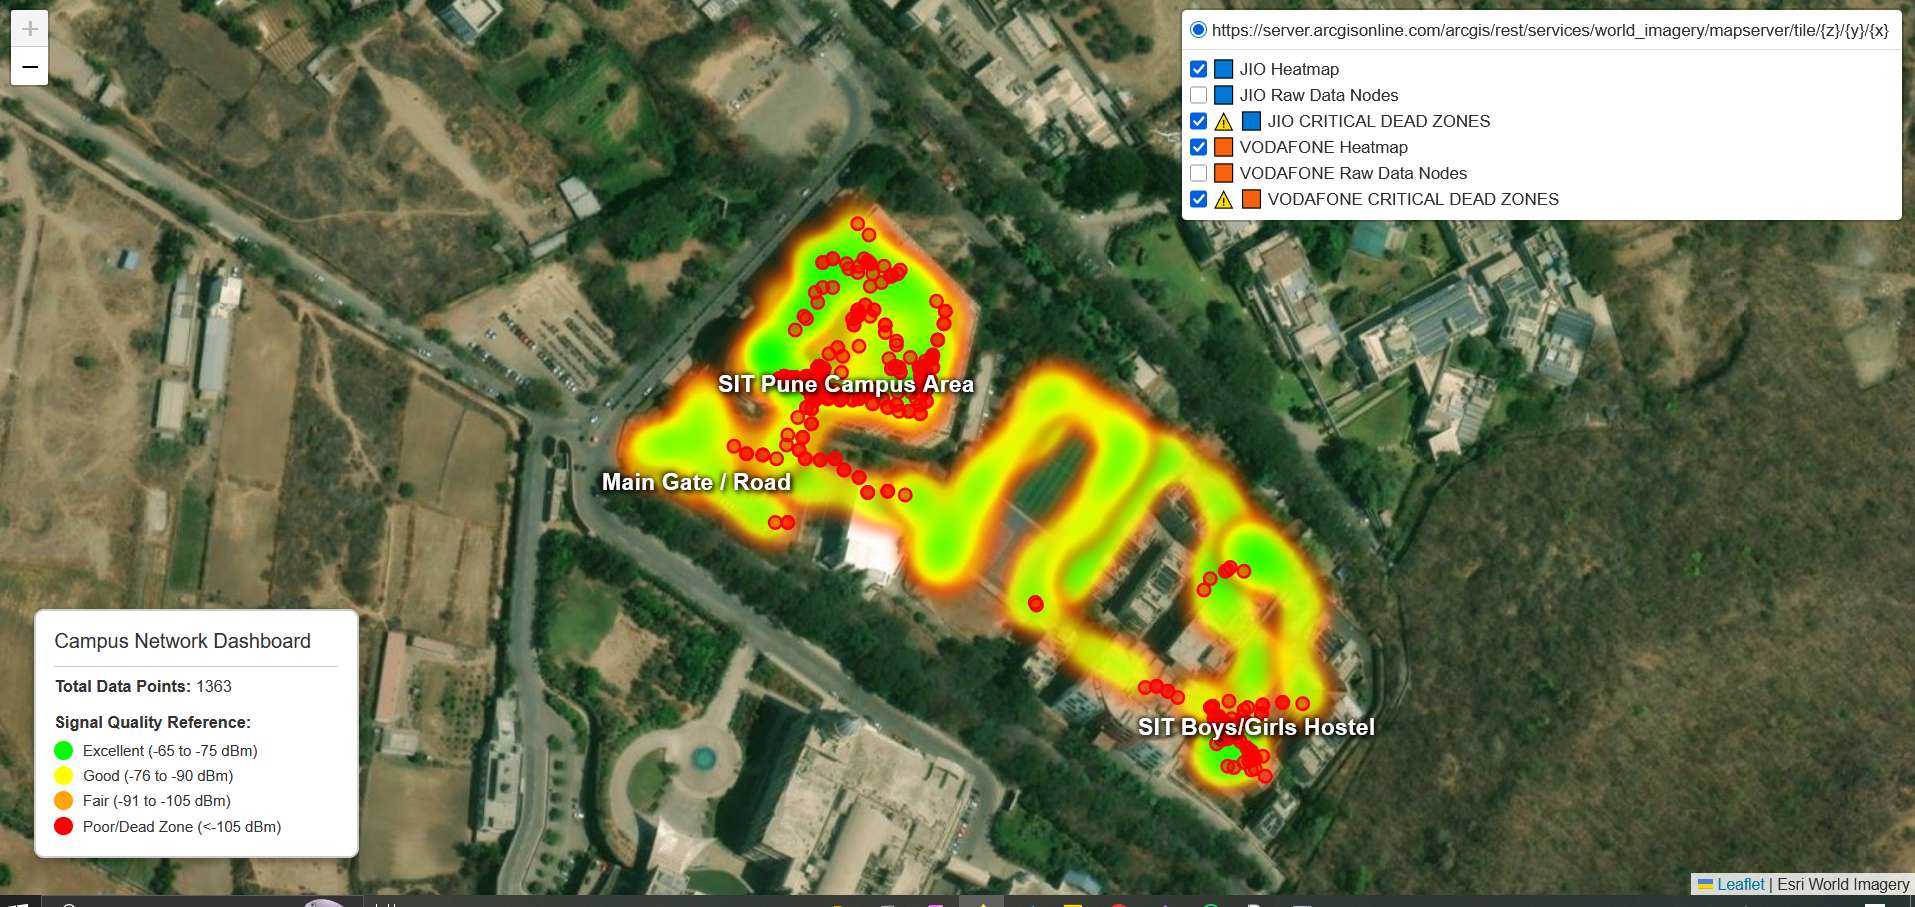

---

## 🏁 Project Conclusion

Project Echelon successfully demonstrates the complete pipeline of Radio Frequency (RF) spatial analysis—from ingesting noisy, multi-format telemetry (CSV) to deploying an interactive, telecom-grade geographic dashboard of the SIT Pune campus.

By engineering custom data-cleaning protocols in Pandas and bypassing standard visualization flaws with our Dead-Zone Override Protocol, we accurately mapped physical network constraints and severe structural blackouts ($<-105$ dBm). This final dashboard translates raw, invisible cellular data into actionable spatial intelligence, proving the direct impact of campus architecture on real-world mobile network performance.

---
*Developed by Arjit Ujjawal & Bedang Das | B.Tech EnTC Sem 1 (A2)*